# NYC Yellow Taxi -- EDA & Data Cleaning
**Lecture 1 · DSMA 2026 · Ben-Gurion University**

This notebook walks through a complete first-pass analysis of one month of NYC Yellow Taxi trip records.
We follow a four-act structure:

| Act | What we do |
|-----|------------|
| 1 -- Fundamentals | Understand the shape and meaning of the data |
| 2 -- Validation | Ask systematic questions: does the data meet our expectations? |
| 3 -- Cleaning | Fix what validation found |
| 4 -- EDA | Data-based storytelling with clean data |

**Dataset:** NYC TLC Yellow Taxi trip records, January 2024

In [1]:
import sys
from pathlib import Path

# Add the project root to sys.path so we can import from src/
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

---
## Act 1 -- Fundamentals
> **Goal:** build a mental model of what the data *is* before we do anything to it.
>
> Every row is one taxi trip. Every column is one fact recorded by the meter or the driver.
> Before we clean, model, or visualise anything, we need to be able to answer:
> *What does a single row represent? What are the units? Which columns could be null?*

In [2]:
DATA_RAW     = Path('..') / 'data' / 'raw'
PARQUET_FILE = DATA_RAW / 'yellow_tripdata_2024-01.parquet'

df = pd.read_parquet(PARQUET_FILE)
print(f'Loaded {len(df):,} rows x {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Loaded 2,964,624 rows x 19 columns
Memory usage: 418.0 MB


In [3]:
# Schema: column names, dtypes, and non-null counts at a glance
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

In [4]:
# Three sample rows -- (a sanity check)
df.head(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.00,1.72,1.00,N,186,79,2,17.70,1.00,0.50,0.00,0.00,1.00,22.70,2.50,0.00
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.00,1.80,1.00,N,140,236,1,10.00,3.50,0.50,3.75,0.00,1.00,18.75,2.50,0.00
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.00,4.70,1.00,N,236,79,1,23.30,3.50,0.50,3.00,0.00,1.00,31.30,2.50,0.00


In [5]:
# Summary statistics for every numeric column
# Look for: surprising min/max values, large std relative to mean, suspicious zeros
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,"2,964,624.00",2964624,2964624,"2,824,462.00","2,964,624.00","2,824,462.00","2,964,624.00","2,964,624.00","2,964,624.00","2,964,624.00","2,964,624.00","2,964,624.00","2,964,624.00","2,964,624.00","2,964,624.00","2,964,624.00","2,824,462.00","2,824,462.00"
mean,1.75,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.34,3.65,2.07,166.02,165.12,1.16,18.18,1.45,0.48,3.34,0.53,0.98,26.80,2.26,0.14
min,1.00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.00,0.00,1.00,1.00,1.00,0.00,-899.00,-7.50,-0.50,-80.00,-80.00,-1.00,-900.00,-2.50,-1.75
25%,2.00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.00,1.00,1.00,132.00,114.00,1.00,8.60,0.00,0.50,1.00,0.00,1.00,15.38,2.50,0.00
50%,2.00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.00,1.68,1.00,162.00,162.00,1.00,12.80,1.00,0.50,2.70,0.00,1.00,20.10,2.50,0.00
75%,2.00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.00,3.11,1.00,234.00,234.00,1.00,20.50,2.50,0.50,4.12,0.00,1.00,28.56,2.50,0.00
max,6.00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.00,"312,722.30",99.00,265.00,265.00,4.00,"5,000.00",14.25,4.00,428.00,115.92,1.00,"5,000.00",2.50,1.75
std,0.43,NaN,NaN,0.85,225.46,9.82,63.62,69.32,0.58,18.95,1.80,0.12,3.90,2.13,0.22,23.39,0.82,0.49


### What does one row represent?

A single row encodes the full lifecycle of one metered taxi trip:

| Column group | What it captures |
|---|---|
| `VendorID` | Which company's hardware recorded this trip |
| `tpep_pickup/dropoff_datetime` | When the trip started and ended |
| `PULocationID / DOLocationID` | Pickup and dropoff taxi zones (1-265) |
| `passenger_count`, `trip_distance` | Trip characteristics |
| `fare_amount`, `tip_amount`, `total_amount` | The money |
| `RatecodeID`, `payment_type` | How the fare was calculated and paid |
| `mta_tax`, `improvement_surcharge`, `congestion_surcharge` | Fixed regulatory add-ons |


> **Looking at `.describe()`**  -- what values look suspicious to you before we even run a single validation check?

---
## Act 2 -- Data Validation
> **Goal:** replace vague intuition with precise, repeatable checks.
>
> A validation check is just a function that takes a dataframe and returns a result dict:
> `{ name, column, passed, detail }`
>
> We will build three check types from scratch to understand the pattern,
> then run the full suite from `src/validation.py`.

In [6]:
# Check type 1: nullability
# The simplest question -- is this column fully populated?

def check_not_null(df, col):
    n_null = df[col].isna().sum()
    passed = int(n_null) == 0
    detail = 'OK' if passed else f'{n_null:,} nulls ({n_null / len(df):.2%} of rows)'
    return {'name': 'not_null', 'column': col, 'passed': passed, 'detail': detail}


check_not_null(df, 'passenger_count')

{'name': 'not_null',
 'column': 'passenger_count',
 'passed': False,
 'detail': '140,162 nulls (4.73% of rows)'}

In [7]:
# Check type 2: value range
# Is every value within a known valid range?

def check_between(df, col, min_value=None, max_value=None):
    mask = pd.Series(True, index=df.index)
    if min_value is not None:
        mask &= df[col] >= min_value
    if max_value is not None:
        mask &= df[col] <= max_value
    fail_rate = (~mask & df[col].notna()).mean()
    passed    = fail_rate == 0
    detail    = 'OK' if passed else f'{fail_rate:.2%} of rows outside [{min_value}, {max_value}]'
    return {'name': f'between[{min_value},{max_value}]', 'column': col, 'passed': passed, 'detail': detail}


# Fares should never be negative
check_between(df, 'fare_amount', min_value=0)

{'name': 'between[0,None]',
 'column': 'fare_amount',
 'passed': np.False_,
 'detail': '1.26% of rows outside [0, None]'}

In [8]:
# Check type 3: column-pair ordering (business logic)
# This is the key insight: some rules span two columns.
# No single-column check can catch them.

def check_pair_gt(df, col_a, col_b):
    both      = df[col_a].notna() & df[col_b].notna()
    violated  = (df[col_a] <= df[col_b]) & both
    fail_rate = violated.mean()
    passed    = fail_rate == 0
    detail    = 'OK' if passed else f'{fail_rate:.2%} of rows have {col_a} <= {col_b}'
    return {'name': f'{col_a}_gt_{col_b}', 'column': f'{col_a}, {col_b}', 'passed': passed, 'detail': detail}


# A trip must end strictly after it starts
check_pair_gt(df, 'tpep_dropoff_datetime', 'tpep_pickup_datetime')

{'name': 'tpep_dropoff_datetime_gt_tpep_pickup_datetime',
 'column': 'tpep_dropoff_datetime, tpep_pickup_datetime',
 'passed': np.False_,
 'detail': '0.03% of rows have tpep_dropoff_datetime <= tpep_pickup_datetime'}

### Packaging checks into a reusable module

These three patterns -- null checks, range checks, pair checks -- cover the vast majority of
real-world data quality rules. We have assembled all the checks for the taxi dataset into
`src/validation.py` so any notebook can import and run them in one call.

This is exactly the workflow of moving code from notebook to `src/`:
1. Prototype in the notebook (what we just did)
2. Generalise and test
3. Move to `src/` so it is reusable and version-controlled

In [9]:
from src.validation import validate_nyc_taxi_parquet

report   = validate_nyc_taxi_parquet(str(PARQUET_FILE))
passed_n = sum(r['passed'] for r in report['results'])
total_n  = len(report['results'])
status   = 'ALL PASSED' if report['success'] else 'SOME CHECKS FAILED'
print(f'Result: {status}  ({passed_n}/{total_n} checks passed)')

Result: SOME CHECKS FAILED  (21/33 checks passed)


In [10]:
# Full results table
print('{:<4} {:<32} {:<48} {}'.format('#', 'Column', 'Check', 'Result'))
print('-' * 95)
for i, r in enumerate(report['results'], 1):
    col    = r['column']
    name   = r['name']
    icon   = 'OK  ' if r['passed'] else 'FAIL'
    print('{:<4} {:<32} {:<48} {}'.format(i, col, name, icon))
    if not r['passed']:
        detail = r['detail']
        print(f'     >> {detail}')

#    Column                           Check                                            Result
-----------------------------------------------------------------------------------------------
1    TABLE                            required_columns_present                         OK  
2    TABLE                            row_count_between(100,000, 10,000,000)           OK  
3    VendorID                         not_null                                         OK  
4    VendorID                         values_in_set(mostly=1.0)                        FAIL
     >> 0.01% outside [1, 2]; top bad values: {6: 260}
5    tpep_pickup_datetime             not_null                                         OK  
6    tpep_pickup_datetime             dtype_is_datetime                                OK  
7    tpep_dropoff_datetime            not_null                                         OK  
8    tpep_dropoff_datetime            dtype_is_datetime                                OK  
9    tpep_dropoff_d

---
## Act 3 -- Data Cleaning
> **Goal:** produce a clean dataframe ready for analysis.
>
> For every failure from Act 2, we make a deliberate decision:
> fix it, filter it out, or flag it. We never silently ignore it.
>
> We write the clean dataset to `data/processed/` so Act 4 and future
> notebooks can use it without re-running the cleaning steps.

In [11]:
df_clean = df.copy()

# Fix 1: ensure datetime columns are actual datetime dtype
# (some parquet writers store them as object/string)
for col in ['tpep_pickup_datetime', 'tpep_dropoff_datetime']:
    if not pd.api.types.is_datetime64_any_dtype(df_clean[col]):
        df_clean[col] = pd.to_datetime(df_clean[col])
        print(f'  Converted {col} to datetime')
    else:
        print(f'  {col} already datetime -- OK')

print(df_clean[['tpep_pickup_datetime', 'tpep_dropoff_datetime']].dtypes)

  tpep_pickup_datetime already datetime -- OK
  tpep_dropoff_datetime already datetime -- OK
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
dtype: object


In [12]:
# Fix 2: handle nulls with an explicit strategy per column
null_counts = df_clean.isna().sum()
print('Columns with nulls before cleaning:')
print(null_counts[null_counts > 0].to_string())
print()

# passenger_count = 0  means "driver did not record" per TLC spec -- fill NaN with 0
# congestion_surcharge / airport_fee -- NaN means the surcharge did not apply -- fill with 0
df_clean['passenger_count'] = df_clean['passenger_count'].fillna(0)
if 'congestion_surcharge' in df_clean.columns:
    df_clean['congestion_surcharge'] = df_clean['congestion_surcharge'].fillna(0)
if 'airport_fee' in df_clean.columns:
    df_clean['airport_fee'] = df_clean['airport_fee'].fillna(0)

remaining = df_clean.isna().sum()
remaining = remaining[remaining > 0]
print('Remaining nulls after fill:')
print(remaining.to_string() if len(remaining) else '  None -- all handled')

Columns with nulls before cleaning:
passenger_count         140162
RatecodeID              140162
store_and_fwd_flag      140162
congestion_surcharge    140162
Airport_fee             140162

Remaining nulls after fill:
RatecodeID            140162
store_and_fwd_flag    140162
Airport_fee           140162


In [13]:
# Fix 3: remove rows that are physically impossible
# We drop rather than impute because there is no sensible value to substitute
n_before = len(df_clean)

mask_time = df_clean['tpep_dropoff_datetime'] > df_clean['tpep_pickup_datetime']
mask_fare = df_clean['fare_amount'] >= 0
mask_dist = df_clean['trip_distance'] >= 0

df_clean = df_clean[mask_time & mask_fare & mask_dist].copy()
n_after  = len(df_clean)

print(f'Removed {n_before - n_after:,} impossible rows ({(n_before - n_after) / n_before:.3%} of total)')
print(f'Clean dataset: {n_after:,} rows')

Removed 38,314 impossible rows (1.292% of total)
Clean dataset: 2,926,310 rows


In [14]:
# Save the clean dataset to data/processed/
# Future notebooks load this file -- they never touch data/raw/
DATA_PROCESSED = Path('..') / 'data' / 'processed'
OUT_FILE       = DATA_PROCESSED / 'yellow_tripdata_2024-01_clean.parquet'

df_clean.to_parquet(OUT_FILE, index=False)
print(f'Saved --> {OUT_FILE}')
print(f'Shape:    {df_clean.shape}')

Saved --> ..\data\processed\yellow_tripdata_2024-01_clean.parquet
Shape:    (2926310, 19)


---
## Act 4 -- Exploratory Data Analysis
> **Goal:** find the stories hidden in the data.
>
> EDA is not about computing statistics -- it is about asking questions
> and letting the data answer. Every plot below starts with a question.
>
> We will work towards answering: *What does a typical NYC taxi trip look like --*
> *and what makes a trip unusual?*

### Story 1 -- The City That Never Sleeps
**Question:** When do people take taxis? Is demand constant throughout the day?

We expect a pattern -- but what exactly does NYC's taxi behavior look like encoded in trip data?

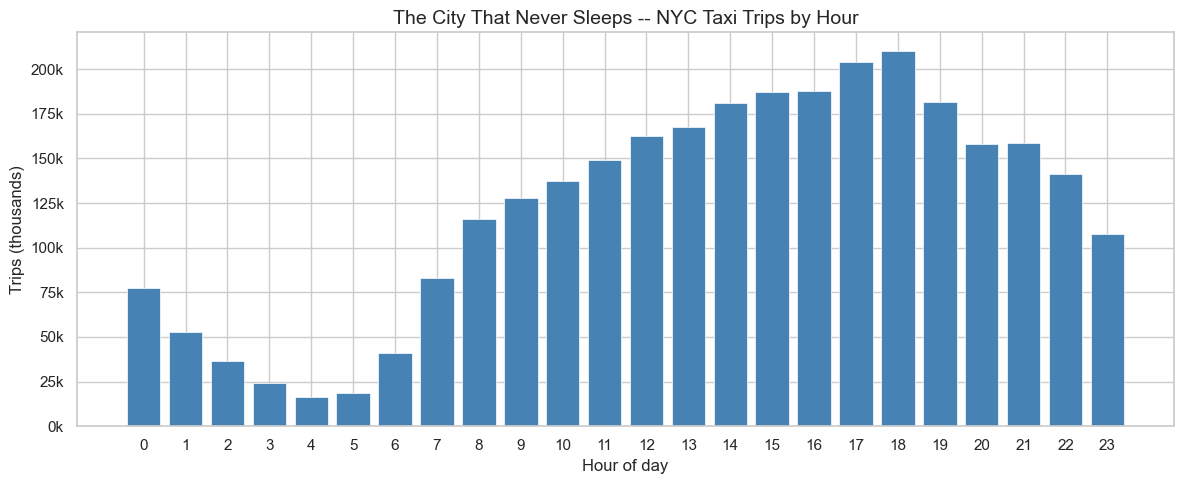

Busiest hour:   18:00  (210,061 trips)
Quietest hour:  04:00  (16,292 trips)
Peak-to-trough ratio: 12.9x


In [15]:
df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour
hourly = df_clean.groupby('pickup_hour').size().reset_index(name='trips')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly['pickup_hour'], hourly['trips'] / 1_000,
       color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Hour of day', fontsize=12)
ax.set_ylabel('Trips (thousands)', fontsize=12)
ax.set_title('The City That Never Sleeps -- NYC Taxi Trips by Hour', fontsize=14)
ax.set_xticks(range(24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
plt.tight_layout()
plt.show()

busiest = hourly.loc[hourly['trips'].idxmax()]
quietest = hourly.loc[hourly['trips'].idxmin()]
print(f'Busiest hour:   {int(busiest.pickup_hour):02d}:00  ({int(busiest.trips):,} trips)')
print(f'Quietest hour:  {int(quietest.pickup_hour):02d}:00  ({int(quietest.trips):,} trips)')
print(f'Peak-to-trough ratio: {busiest.trips / quietest.trips:.1f}x')

> **What can you infer from this?** One would expect whoever took taxis in the morning also took taxis in the evening - why isn't the distribution having two peaks? 

> **Do you expect the busiest hours to be the costliest trips?** 

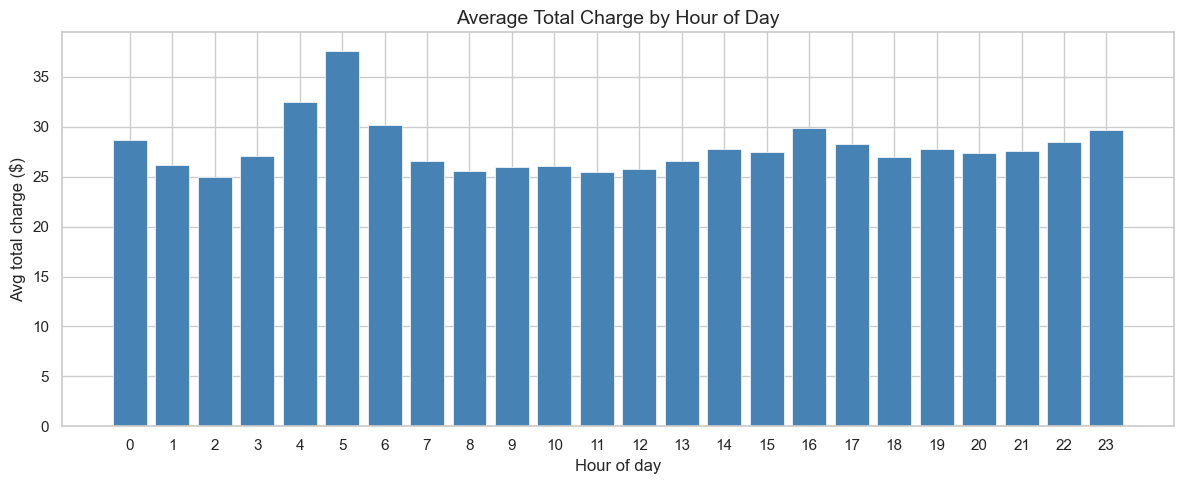

In [16]:
df_clean['hour'] = df_clean['tpep_pickup_datetime'].dt.hour
avg_charge = df_clean.groupby('hour')['total_amount'].mean()

fig6, ax6 = plt.subplots(figsize=(12, 5))
ax6.bar(avg_charge.index, avg_charge.values, color='steelblue',
        edgecolor='white', linewidth=0.5)
ax6.set_xlabel('Hour of day', fontsize=12)
ax6.set_ylabel('Avg total charge ($)', fontsize=12)
ax6.set_title('Average Total Charge by Hour of Day', fontsize=14)
ax6.set_xticks(range(24))
plt.tight_layout()
plt.show()


> **Do you notice anything interesting in the distribution of average charge?** Hours 5, 16 and 18 are worth inspecting

#### Are there different behaviors in different parts of the city?

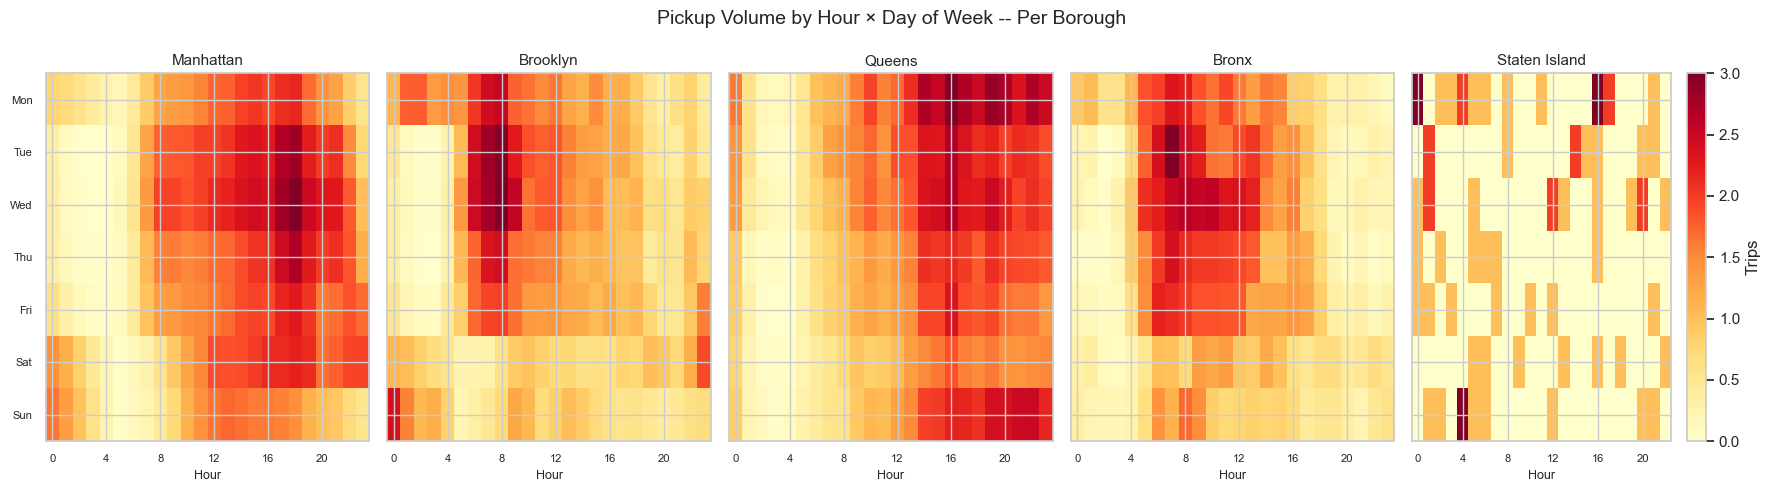

In [17]:
ZONE_LOOKUP = Path('..')/ 'data' / 'raw' /'taxi_zone_lookup.csv'   # adjust path if needed
zones = pd.read_csv(ZONE_LOOKUP)[['LocationID', 'Borough']]

# merging a dataframe is like merging tables in sql 
# what we do here is to merge the data from two sources:
# the data/processed/yellow_tripdata_2024-01_clean.parquet file
# and data/raw/taxi_zone_lookup.csv file
# the 'key' that we use to merge is named differently in each data source, but essentially contain the same values
# this way, we "obtain" the borough names from the taxi_zone_lookup.csv into the parquet data.

df_borough = df_clean.merge(zones, left_on='PULocationID', right_on='LocationID', how='left')

df_borough['day_of_week'] = df_borough['tpep_pickup_datetime'].dt.dayofweek  # 0=Mon
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

boroughs = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
df_borough = df_borough[df_borough['Borough'].isin(boroughs)]

fig7, axes7 = plt.subplots(1, len(boroughs), figsize=(18, 5), sharey=True)
for ax, borough in zip(axes7, boroughs):
    pivot = (
        df_borough[df_borough['Borough'] == borough]
        .groupby(['day_of_week', 'hour'])
        .size()
        .unstack(fill_value=0)
    )
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', origin='upper')
    ax.set_title(borough, fontsize=11)
    ax.set_xlabel('Hour', fontsize=9)
    ax.set_xticks(range(0, 24, 4))
    ax.set_xticklabels(range(0, 24, 4), fontsize=8)
    ax.set_yticks(range(7))
    ax.set_yticklabels(day_labels, fontsize=8)

fig7.colorbar(im, ax=axes7[-1], label='Trips')
fig7.suptitle('Pickup Volume by Hour × Day of Week -- Per Borough', fontsize=14)
plt.tight_layout()
plt.show()


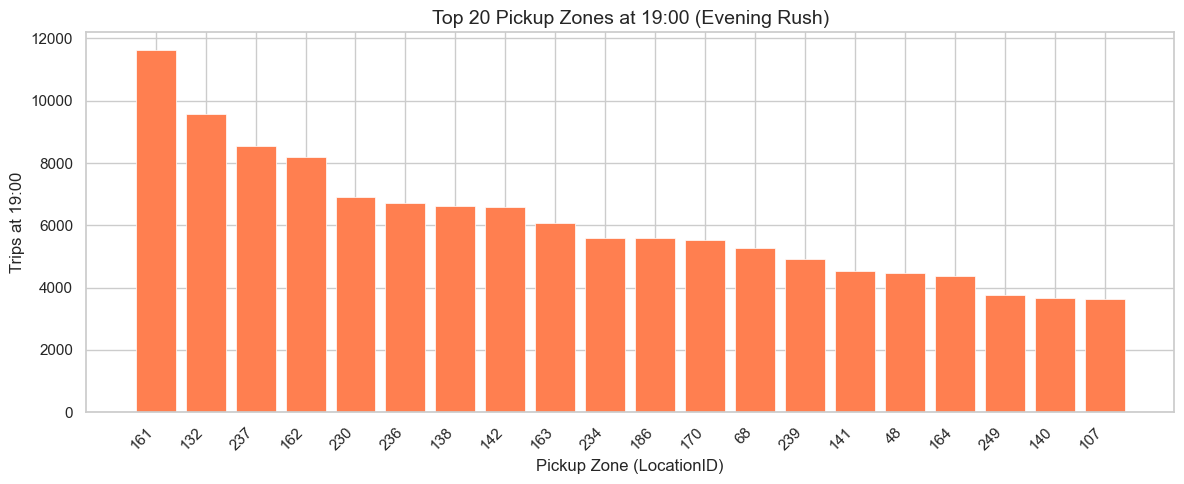

In [18]:
hour_19 = df_clean[df_clean['hour'] == 19]
zone_counts = (
    hour_19.groupby('PULocationID')
    .size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='trips')
)

fig8, ax8 = plt.subplots(figsize=(12, 5))
ax8.bar(zone_counts['PULocationID'].astype(str), zone_counts['trips'],
        color='coral', edgecolor='white', linewidth=0.5)
ax8.set_xlabel('Pickup Zone (LocationID)', fontsize=12)
ax8.set_ylabel('Trips at 19:00', fontsize=12)
ax8.set_title('Top 20 Pickup Zones at 19:00 (Evening Rush)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Question 2 -- Let's take a look at distributions of trips across fare and distance 
**Expectation:** We should expect to see fare and distance having similar distributions.



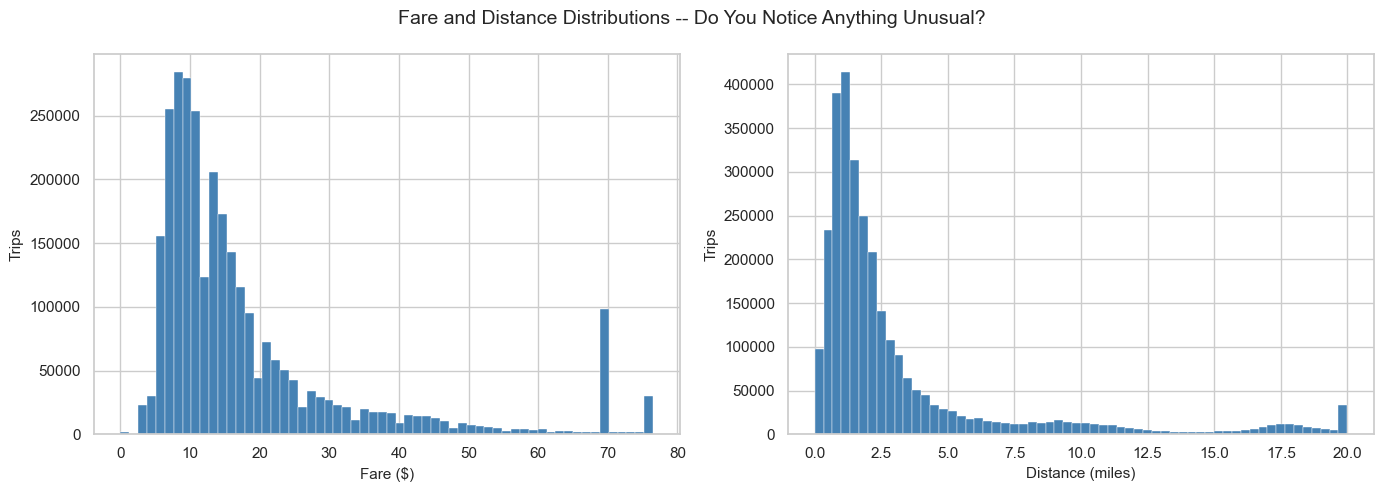

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols   = ['fare_amount', 'trip_distance']
labels = ['Fare ($)', 'Distance (miles)']
for ax, col, label in zip(axes, cols, labels):
    cap = df_clean[col].quantile(0.99)
    ax.hist(df_clean[col].clip(upper=cap), bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Trips', fontsize=11)
fig.suptitle('Fare and Distance Distributions -- Do You Notice Anything Unusual?', fontsize=14)
plt.tight_layout()
plt.show()

> **Do you see anything strange?** Both distributions have a suspicious bump on the right tail -- a second hump that doesn't fit the main cluster. What kind of trips might form a separate population with systematically higher fares and longer distances?

### Story 2 -- The Airport Effect
**Question:** Are airport trips fundamentally different from regular trips?

JFK (zone 132), LaGuardia (zone 138), and Newark (zone 1) trips follow fixed routes
with flat-rate options. If they are a distinct population, our data contains **two datasets
pretending to be one** -- a common and dangerous modelling trap.

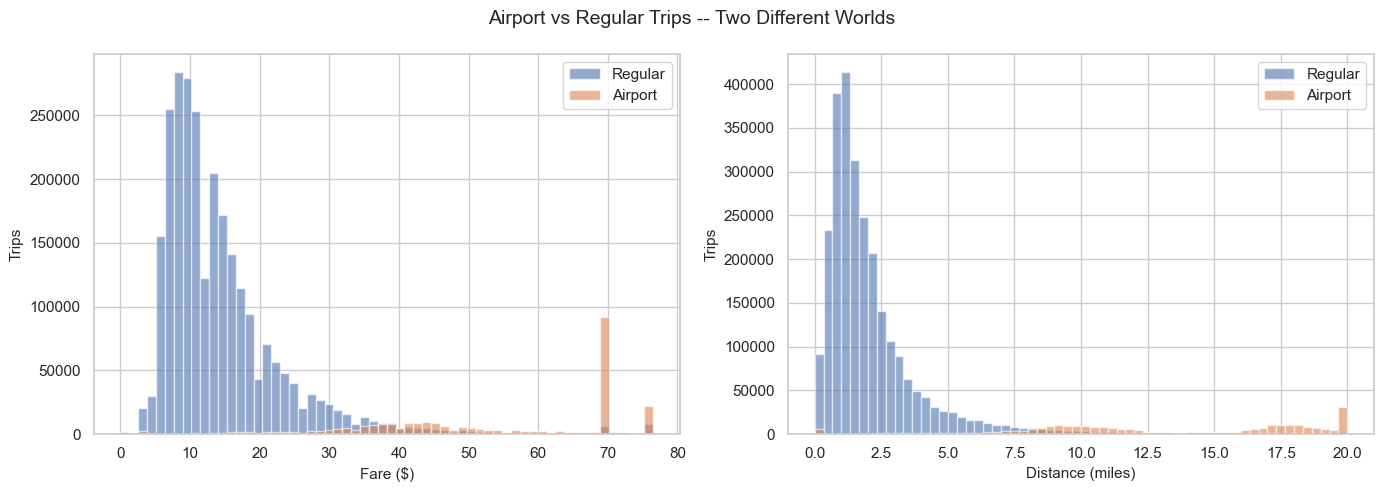

            fare_amount  trip_distance  tip_amount
is_airport                                        
Regular           14.61           2.57        2.73
Airport           55.73          13.71        9.34


In [20]:
airport_zones = {132, 138, 1}   # JFK=132, LGA=138, EWR=1
df_clean['is_airport'] = (
    df_clean['DOLocationID'].isin(airport_zones) |
    df_clean['PULocationID'].isin(airport_zones)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols   = ['fare_amount', 'trip_distance']
labels = ['Fare ($)', 'Distance (miles)']
for ax, col, label in zip(axes, cols, labels):
    cap = df_clean[col].quantile(0.99)
    for flag, grp in df_clean.groupby('is_airport'):
        name = 'Airport' if flag else 'Regular'
        ax.hist(grp[col].clip(upper=cap), bins=60, alpha=0.6, label=name)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Trips', fontsize=11)
    ax.legend()
fig.suptitle('Airport vs Regular Trips -- Two Different Worlds', fontsize=14)
plt.tight_layout()
plt.show()

print(df_clean.groupby('is_airport')[['fare_amount', 'trip_distance', 'tip_amount']]
      .mean()
      .rename(index={False: 'Regular', True: 'Airport'})
      .to_string())

### Story 3 -- The Tip Mystery
**Question:** Why does the tip distribution have a massive spike at exactly zero?

At first glance, it looks like most passengers don't tip. But is that really true,
or is the data hiding something? Think before you look at the next cell.

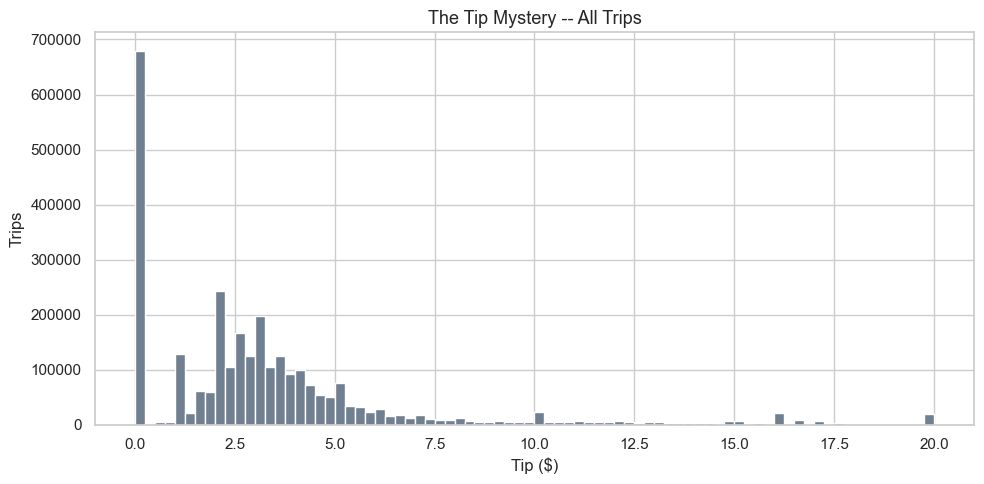

In [21]:
# The mystery
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.hist(df_clean['tip_amount'].clip(upper=20), bins=80, color='slategray')
ax1.set_title('The Tip Mystery -- All Trips', fontsize=13)
ax1.set_xlabel('Tip ($)')
ax1.set_ylabel('Trips')
plt.tight_layout()
plt.show()


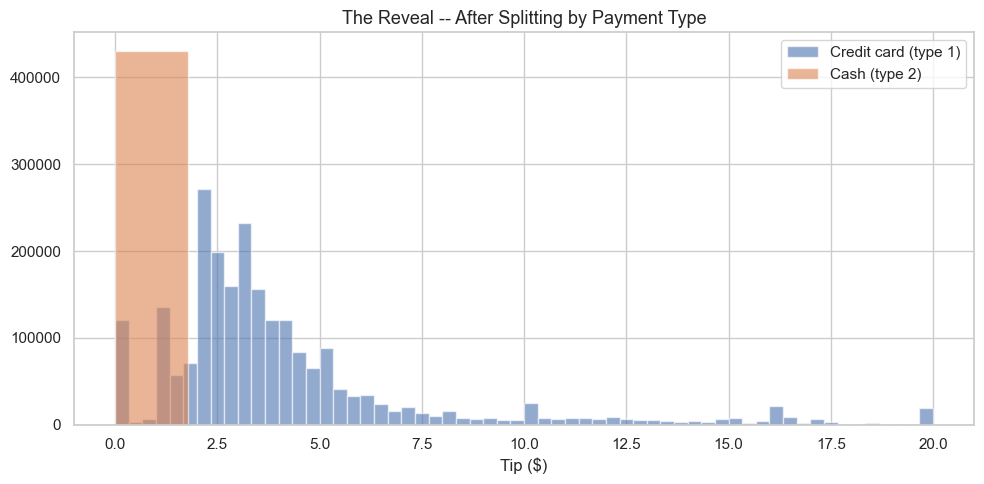

Credit card  -- mean tip: $4.17
Cash         -- mean tip: $0.00   (100.0% of cash trips show $0)

Cash tips never reach the meter. The $0 entries are not stingy passengers
-- they are a data-recording artefact. The zero-spike was never about tipping.


In [22]:
# The reveal
cc   = df_clean.loc[df_clean['payment_type'] == 1, 'tip_amount']
cash = df_clean.loc[df_clean['payment_type'] == 2, 'tip_amount']
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.hist(cc.clip(upper=20),   bins=60, alpha=0.6, label='Credit card (type 1)')
ax2.hist(cash.clip(upper=20), bins=5,  alpha=0.6, label='Cash (type 2)')
ax2.set_title('The Reveal -- After Splitting by Payment Type', fontsize=13)
ax2.set_xlabel('Tip ($)')
ax2.legend()
plt.tight_layout()
plt.show()

print(f'Credit card  -- mean tip: ${cc.mean():.2f}')
print(f'Cash         -- mean tip: ${cash.mean():.2f}   ({(cash == 0).mean():.1%} of cash trips show $0)')
print()
print('Cash tips never reach the meter. The $0 entries are not stingy passengers')
print('-- they are a data-recording artefact. The zero-spike was never about tipping.')

### Story 4 -- Price Per Mile Is Not What You Think
**Question:** If the NYC taxi meter charges a fixed rate per mile, why isn't
`fare / distance` a constant?

This question teaches one of the most important EDA instincts: **derived features
can reveal structure that raw columns hide**.

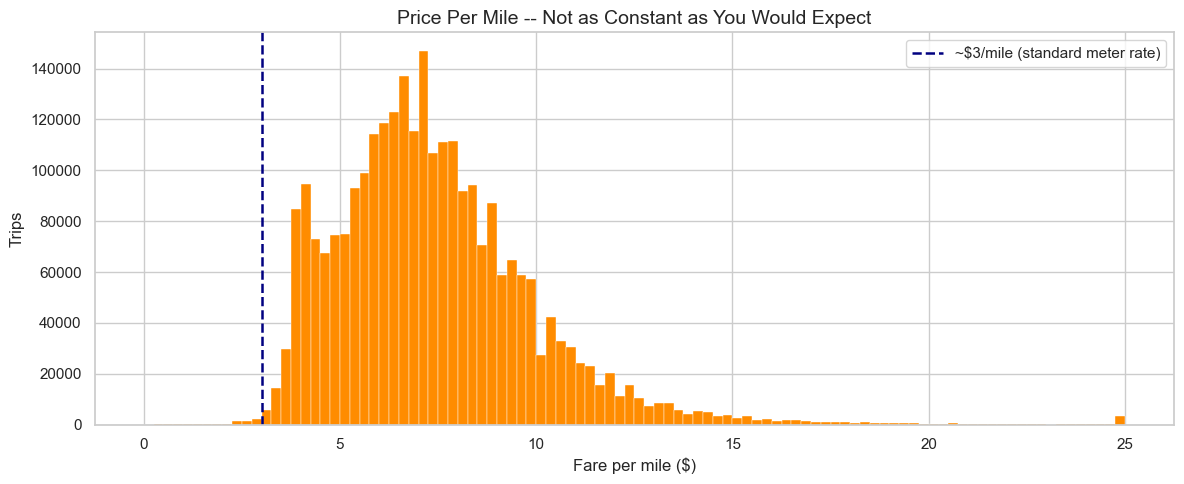

Median: $7.09/mile    Mean: $7.42/mile
10th pct: $4.37     90th pct: $10.49

Why the spread? Short trips pay a $3 minimum fare regardless of distance.
Airport flat rates (RatecodeID=2) break the per-mile model entirely.
Rate codes, minimum fares, and surcharges all bend the meter rate.


In [23]:
valid = df_clean[(df_clean['trip_distance'] > 0.5) & (df_clean['fare_amount'] > 2.5)].copy()
valid['price_per_mile'] = valid['fare_amount'] / valid['trip_distance']

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(valid['price_per_mile'].clip(upper=25), bins=100,
        color='darkorange', edgecolor='white', linewidth=0.3)
ax.axvline(x=3.0, color='navy', linestyle='--', linewidth=1.8,
           label='~$3/mile (standard meter rate)')
ax.set_xlabel('Fare per mile ($)', fontsize=12)
ax.set_ylabel('Trips', fontsize=12)
ax.set_title('Price Per Mile -- Not as Constant as You Would Expect', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

ppm = valid['price_per_mile']
print(f'Median: ${ppm.median():.2f}/mile    Mean: ${ppm.mean():.2f}/mile')
print(f'10th pct: ${ppm.quantile(0.10):.2f}     90th pct: ${ppm.quantile(0.90):.2f}')
print()
print('Why the spread? Short trips pay a $3 minimum fare regardless of distance.')
print('Airport flat rates (RatecodeID=2) break the per-mile model entirely.')
print('Rate codes, minimum fares, and surcharges all bend the meter rate.')

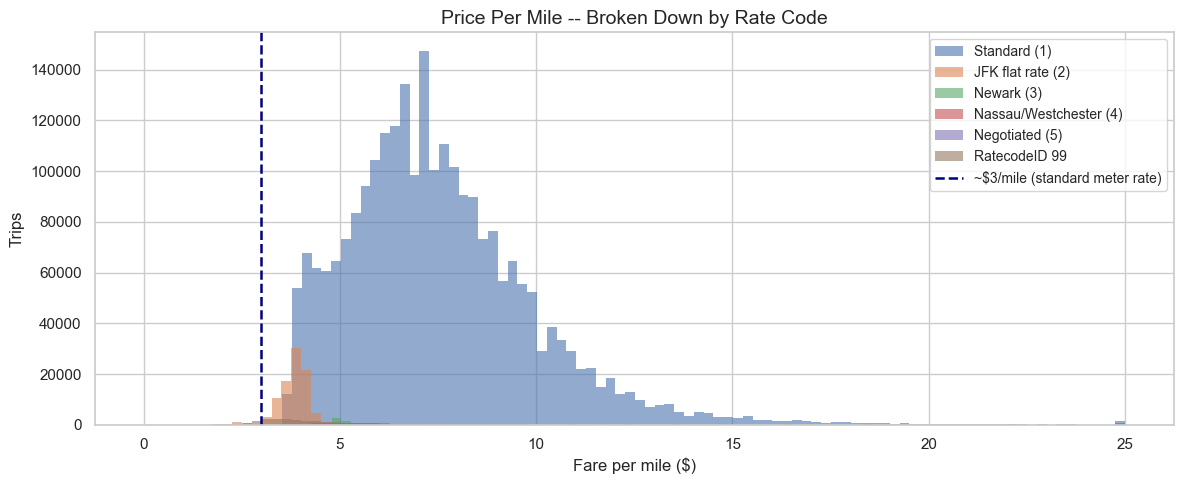

In [24]:
# Second chart: same distribution, coloured by RatecodeID
ratecode_labels = {
    1: 'Standard (1)',
    2: 'JFK flat rate (2)',
    3: 'Newark (3)',
    4: 'Nassau/Westchester (4)',
    5: 'Negotiated (5)',
    6: 'Group ride (6)',
}

fig2, ax2 = plt.subplots(figsize=(12, 5))
for code, grp in valid.groupby('RatecodeID'):
    label = ratecode_labels.get(int(code), f'RatecodeID {int(code)}')
    ax2.hist(grp['price_per_mile'].clip(upper=25), bins=100,
             alpha=0.6, label=label, edgecolor='none')
ax2.axvline(x=3.0, color='navy', linestyle='--', linewidth=1.8,
            label='~$3/mile (standard meter rate)')
ax2.set_xlabel('Fare per mile ($)', fontsize=12)
ax2.set_ylabel('Trips', fontsize=12)
ax2.set_title('Price Per Mile -- Broken Down by Rate Code', fontsize=14)
ax2.legend(fontsize=10)
plt.tight_layout()
plt.show()

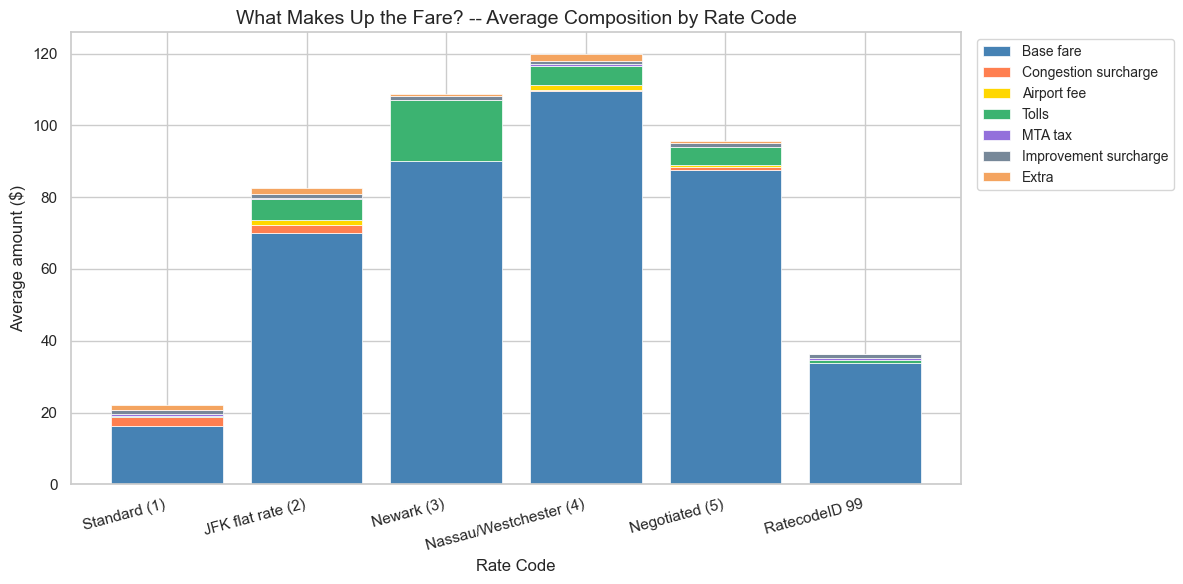

In [25]:

# Third chart: stacked bar showing average fare composition by RatecodeID
surcharge_cols = ['fare_amount', 'congestion_surcharge', 'Airport_fee',
                  'tolls_amount', 'mta_tax', 'improvement_surcharge', 'extra']
surcharge_colors = ['steelblue', 'coral', 'gold', 'mediumseagreen',
                    'mediumpurple', 'lightslategray', 'sandybrown']
surcharge_display = ['Base fare', 'Congestion surcharge', 'Airport fee',
                     'Tolls', 'MTA tax', 'Improvement surcharge', 'Extra']

composition = (
    valid.groupby('RatecodeID')[surcharge_cols]
    .mean()
    .rename(index=lambda c: ratecode_labels.get(int(c), f'RatecodeID {int(c)}'))
)

fig3, ax3 = plt.subplots(figsize=(12, 6))
bottom = None
for col, color, display in zip(surcharge_cols, surcharge_colors, surcharge_display):
    vals = composition[col]
    ax3.bar(composition.index, vals, bottom=bottom, label=display,
            color=color, edgecolor='white', linewidth=0.5)
    bottom = vals if bottom is None else bottom + vals

ax3.set_xlabel('Rate Code', fontsize=12)
ax3.set_ylabel('Average amount ($)', fontsize=12)
ax3.set_title('What Makes Up the Fare? -- Average Composition by Rate Code', fontsize=14)
ax3.legend(fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

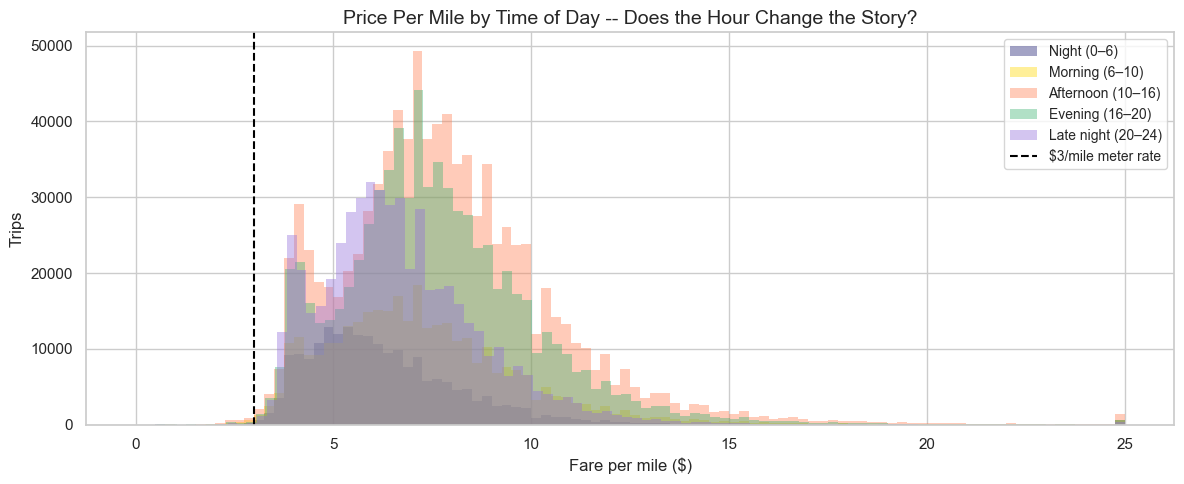

In [26]:
# Fourth chart: price per mile distribution by time of day
time_of_day_bins  = [0,  6,  10,  16,  20,  24]
time_of_day_labels = ['Night (0–6)', 'Morning (6–10)', 'Afternoon (10–16)', 'Evening (16–20)', 'Late night (20–24)']
time_of_day_colors = ['midnightblue', 'gold', 'coral', 'mediumseagreen', 'mediumpurple']

valid['hour'] = valid['tpep_pickup_datetime'].dt.hour
valid['time_of_day'] = pd.cut(valid['hour'], bins=time_of_day_bins,
                               labels=time_of_day_labels, right=False)

fig5, ax5 = plt.subplots(figsize=(12, 5))
for label, color in zip(time_of_day_labels, time_of_day_colors):
    grp = valid[valid['time_of_day'] == label]
    ax5.hist(grp['price_per_mile'].clip(upper=25), bins=100,
             alpha=0.4, label=label, color=color, edgecolor='none')

ax5.axvline(x=3.0, color='black', linestyle='--', linewidth=1.5,
            label='$3/mile meter rate')
ax5.set_xlabel('Fare per mile ($)', fontsize=12)
ax5.set_ylabel('Trips', fontsize=12)
ax5.set_title('Price Per Mile by Time of Day -- Does the Hour Change the Story?', fontsize=14)
ax5.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Story 5 -- Weekday vs Weekend: Two Cities in One Dataset
**Question:** Do New Yorkers use taxis differently on weekends?

We expect the answer is yes -- but *how* differently, and at what hours?
This is the kind of temporal segmentation that matters enormously for
demand forecasting and pricing models.

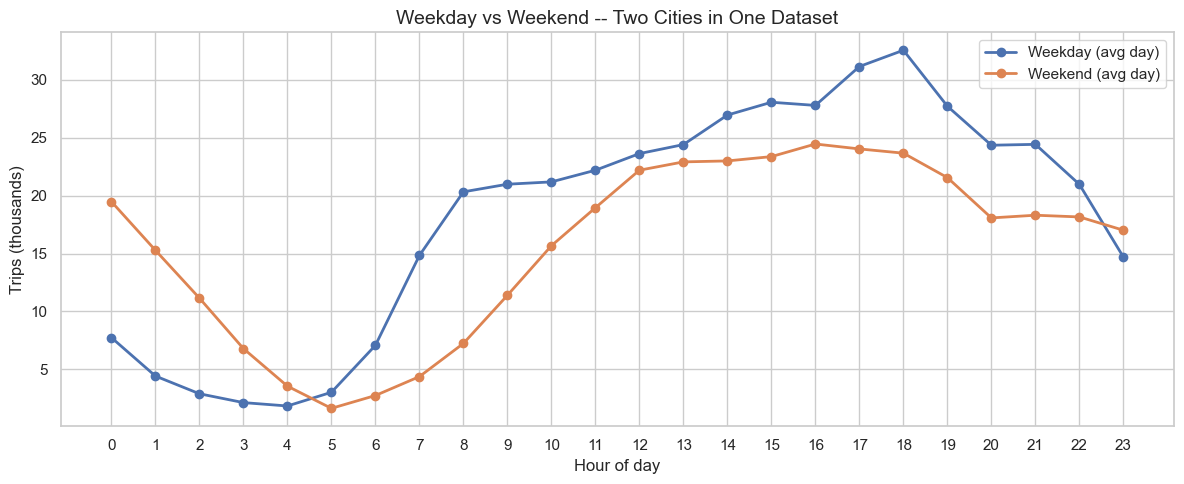

Weekday peak hour: 18:00  (32.5k trips/hr avg)
Weekend peak hour: 16:00  (24.5k trips/hr avg)

Weekdays: sharp morning and evening commute spikes.
Weekends: flat demand all day, then a late-night surge (bars closing).
A single model trained on all days will underfit both patterns.


In [27]:
df_clean['day_of_week'] = df_clean['tpep_pickup_datetime'].dt.dayofweek  # 0=Mon, 6=Sun
df_clean['is_weekend']  = df_clean['day_of_week'] >= 5  
df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour

# Average trips per hour per day-type (normalise by number of days in each group)
n_weekdays = df_clean.loc[~df_clean['is_weekend'], 'day_of_week'].nunique()
n_weekends = df_clean.loc[ df_clean['is_weekend'], 'day_of_week'].nunique()

hourly_wd = df_clean[~df_clean['is_weekend']].groupby('pickup_hour').size() / n_weekdays
hourly_we = df_clean[ df_clean['is_weekend']].groupby('pickup_hour').size() / n_weekends

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_wd.index, hourly_wd.values / 1_000,
        marker='o', linewidth=2, label='Weekday (avg day)')
ax.plot(hourly_we.index, hourly_we.values / 1_000,
        marker='o', linewidth=2, label='Weekend (avg day)')
ax.set_xlabel('Hour of day', fontsize=12)
ax.set_ylabel('Trips (thousands)', fontsize=12)
ax.set_title('Weekday vs Weekend -- Two Cities in One Dataset', fontsize=14)
ax.set_xticks(range(24))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

wd_peak = hourly_wd.idxmax()
we_peak = hourly_we.idxmax()
print(f'Weekday peak hour: {wd_peak:02d}:00  ({hourly_wd[wd_peak] / 1000:.1f}k trips/hr avg)')
print(f'Weekend peak hour: {we_peak:02d}:00  ({hourly_we[we_peak] / 1000:.1f}k trips/hr avg)')
print()
print('Weekdays: sharp morning and evening commute spikes.')
print('Weekends: flat demand all day, then a late-night surge (bars closing).')
print('A single model trained on all days will underfit both patterns.')